# A/B тест: влияние нового варианта на конверсию и выручку

**План:** 1) проверка данных → 2) описательная статистика → 3) гипотезы → 4) проверка гипотез → 5) вывод

**Метрики:**
- **Конверсия** — доля пользователей с выручкой > 0
- **ARPU** — средняя выручка на пользователя (включая нулевую)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multitest import multipletests

sns.set_theme(style="whitegrid")
ALPHA = 0.05

## 1. Проверка корректности данных

In [2]:
df_raw = pd.read_csv("AB_Test_Results.csv")
df_raw.columns = ["user_id", "group", "revenue"]

print("Размер:", df_raw.shape)
print("Пропуски:", df_raw.isna().sum().sum())
print("Группы:", df_raw["group"].unique())
print("Отрицательная выручка:", (df_raw["revenue"] < 0).sum())
df_raw.head()

Размер: (10000, 3)
Пропуски: 0
Группы: <StringArray>
['variant', 'control']
Length: 2, dtype: str
Отрицательная выручка: 0


,user_id,group,revenue
0,737,variant,0.0
1,2423,control,0.0
2,9411,control,0.0
3,7311,control,0.0
4,6174,variant,0.0


В A/B тесте каждый пользователь должен попадать **только в одну группу**. Проверим, нет ли дублей и пересечений между группами.

In [3]:
n_users = df_raw["user_id"].nunique()
rows_per_user = df_raw.groupby("user_id").size()
groups_per_user = df_raw.groupby("user_id")["group"].nunique()
users_in_both = groups_per_user[groups_per_user > 1].index

print(f"Строк: {len(df_raw)}, уникальных пользователей: {n_users}")
print(f"Пользователей с несколькими строками: {(rows_per_user > 1).sum()} ({(rows_per_user > 1).mean():.1%})")
print(f"Пользователей в обеих группах: {len(users_in_both)} ({len(users_in_both) / n_users:.1%})")

Строк: 10000, уникальных пользователей: 6324
Пользователей с несколькими строками: 2660 (42.1%)
Пользователей в обеих группах: 1541 (24.4%)


**Что делаем с проблемными данными (допущения):**
- пользователей из **обеих групп исключаем** — непонятно, какой вариант повлиял на их поведение;
- несколько строк одного пользователя **внутри группы** считаем его повторными покупками и **суммируем** выручку.

В итоге получаем одну строку на пользователя.

In [4]:
df = (df_raw[~df_raw["user_id"].isin(users_in_both)]
      .groupby(["user_id", "group"], as_index=False)["revenue"].sum())
df["paid"] = (df["revenue"] > 0).astype(int)

assert df["user_id"].is_unique
print(f"Осталось пользователей: {len(df)} из {n_users}")
df["group"].value_counts()

Осталось пользователей: 4783 из 6324


group
variant    2393
control    2390
Name: count, dtype: int64

**Проверка Sample Ratio Mismatch (SRM):** группы должны быть примерно равны (деление 50/50). Проверяем хи-квадратом; для SRM используют строгий порог p < 0.001.

In [5]:
counts = df["group"].value_counts()
chi2, p_srm = stats.chisquare(counts)
print(f"p-value = {p_srm:.4f} →", "SRM есть, данным нельзя доверять" if p_srm < 0.001 else "SRM не обнаружен")

p-value = 0.9654 → SRM не обнаружен


## 2. Описательная статистика

In [6]:
control = df[df["group"] == "control"]
variant = df[df["group"] == "variant"]

summary = df.groupby("group").agg(
    users=("user_id", "count"),
    payers=("paid", "sum"),
    conversion=("paid", "mean"),
    arpu=("revenue", "mean"),
    std=("revenue", "std"),
    max_revenue=("revenue", "max"),
)
summary

,users,payers,conversion,arpu,std,max_revenue
group,,,,,,
control,2390,54,0.022594,0.196887,4.172201,196.01
variant,2393,42,0.017551,0.074935,0.858207,23.04


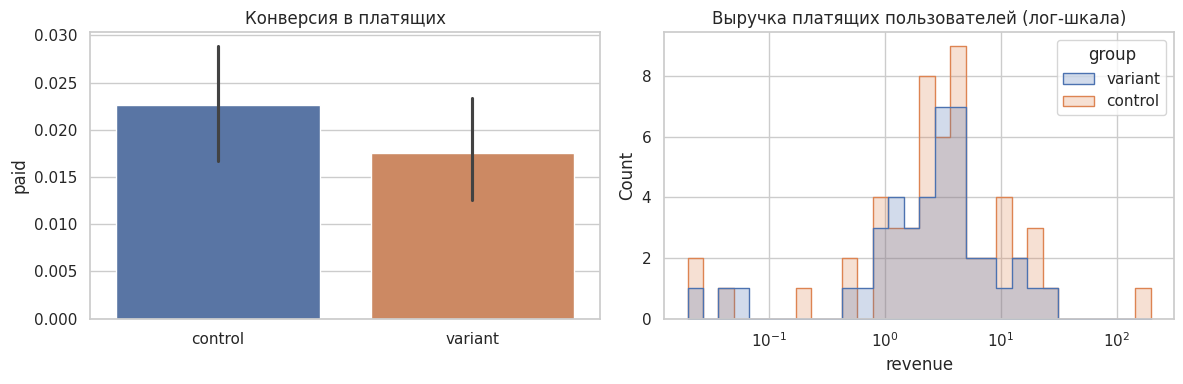

In [7]:
paying = df[df["paid"] == 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=df, x="group", y="paid", ax=axes[0], hue="group", legend=False)
axes[0].set_title("Конверсия в платящих"); axes[0].set_xlabel("")

sns.histplot(data=paying, x="revenue", hue="group", log_scale=True, bins=30, element="step", ax=axes[1])
axes[1].set_title("Выручка платящих пользователей (лог-шкала)")

plt.tight_layout(); plt.show()

**Наблюдения:** почти все пользователи ничего не платят (выручка в основном нулевая), а среди платящих распределение сильно скошено вправо с отдельными крупными покупками. Поэтому для выручки нельзя полагаться только на t-тест (он предполагает нормальность) — добавим непараметрический критерий и бутстрап.

## 3. Формулировка гипотез

Уровень значимости α = 0.05, тесты двусторонние. Эффект = `variant − control`.

**Конверсия** (p — доля платящих)
- H₀: p_variant = p_control
- H₁: p_variant ≠ p_control

**ARPU** (μ — средняя выручка на пользователя)
- H₀: μ_variant = μ_control
- H₁: μ_variant ≠ μ_control

## 4. Проверка гипотез

Для бутстрапа используем готовую функцию `scipy.stats.bootstrap`: она много раз перевыбирает пользователей с возвращением в каждой группе и строит доверительный интервал разницы средних. Если интервал содержит 0 — различие статистически не значимо.

In [8]:
def bootstrap_diff_ci(a, b):
    """95% бутстрап-интервал разницы средних (a - b)."""
    res = stats.bootstrap((a, b), lambda x, y, axis: x.mean(axis=axis) - y.mean(axis=axis),
                          vectorized=True, n_resamples=10_000, method="percentile")
    return res.confidence_interval.low, res.confidence_interval.high

### 4.1 Конверсия
- **z-тест для двух долей** — стандартный критерий для бинарной метрики (платящих достаточно много для его применимости, ожидаемые частоты ≫ 5)
- **Бутстрап** — доверительный интервал разницы конверсий

In [9]:
x = [variant["paid"].sum(), control["paid"].sum()]
n = [len(variant), len(control)]

_, p_conv = proportions_ztest(x, n)
ci_low, ci_high = bootstrap_diff_ci(variant["paid"].values, control["paid"].values)
diff = variant["paid"].mean() - control["paid"].mean()

print(f"Конверсия: control = {control['paid'].mean():.2%}, variant = {variant['paid'].mean():.2%}")
print(f"Разница: {diff * 100:+.2f} п.п.")
print(f"z-тест: p-value = {p_conv:.4f}")
print(f"Бутстрап 95% ДИ разницы: [{ci_low * 100:.2f}; {ci_high * 100:.2f}] п.п.")

Конверсия: control = 2.26%, variant = 1.76%
Разница: -0.50 п.п.
z-тест: p-value = 0.2137
Бутстрап 95% ДИ разницы: [-1.30; 0.29] п.п.


### 4.2 ARPU
- **t-тест Уэлча** — классический критерий для сравнения средних (не требует равенства дисперсий)
- **Манн-Уитни** — непараметрическая проверка, не требующая нормальности (сравнивает распределения целиком, а не средние)
- **Бутстрап** — доверительный интервал разницы средних, не зависит от формы распределения

In [10]:
rev_v, rev_c = variant["revenue"].values, control["revenue"].values

_, p_arpu = stats.ttest_ind(rev_v, rev_c, equal_var=False)
_, p_mw = stats.mannwhitneyu(rev_v, rev_c)
ci_low, ci_high = bootstrap_diff_ci(rev_v, rev_c)

print(f"ARPU: control = {rev_c.mean():.3f}, variant = {rev_v.mean():.3f}")
print(f"Разница: {rev_v.mean() - rev_c.mean():+.3f} ({rev_v.mean() / rev_c.mean() - 1:+.0%})")
print(f"t-тест Уэлча: p-value = {p_arpu:.4f}")
print(f"Манн-Уитни: p-value = {p_mw:.4f}")
print(f"Бутстрап 95% ДИ разницы: [{ci_low:.3f}; {ci_high:.3f}]")

ARPU: control = 0.197, variant = 0.075
Разница: -0.122 (-62%)
t-тест Уэлча: p-value = 0.1617
Манн-Уитни: p-value = 0.2105
Бутстрап 95% ДИ разницы: [-0.320; 0.003]


### 4.3 Поправка на множественные сравнения
Мы проверяем две метрики, поэтому растёт риск ложноположительного результата. Применяем поправку Холма к основным p-value (z-тест и t-тест Уэлча).

In [11]:
reject, p_adj, _, _ = multipletests([p_conv, p_arpu], alpha=ALPHA, method="holm")
pd.DataFrame({"метрика": ["Конверсия", "ARPU"], "p-value": [p_conv, p_arpu],
              "p-value (Холм)": p_adj, "значимо": reject})

,метрика,p-value,p-value (Холм),значимо
0,Конверсия,0.213709,0.323447,False
1,ARPU,0.161724,0.323447,False


## 5. Вывод

**Статистически значимых различий между `variant` и `control` не обнаружено ни по конверсии, ни по ARPU.**

| Метрика | control | variant | Разница | p-value | 95% бутстрап-ДИ (≈) |
|---|---|---|---|---|---|
| Конверсия | 2.26% | 1.76% | −0.50 п.п. | 0.21 (z-тест) | [−1.3; +0.3] п.п. |
| ARPU | 0.197 | 0.075 | −0.122 (−62%) | 0.16 (Уэлч), 0.21 (Манн-Уитни) | [−0.33; 0.00] |

- Все критерии дают один и тот же результат, интервалы бутстрапа включают 0 (или почти касаются его для ARPU), поправка Холма (p ≈ 0.32) значимости не добавляет. Нулевые гипотезы **не отвергаем**.
- Точечные оценки в `variant` ниже по обеим метрикам, но это **не доказывает ухудшение**: платящих всего 96 (54 и 42), поэтому интервалы очень широкие. Отсутствие значимости означает «данных недостаточно», а не «эффекта нет».
- Разница в ARPU особенно нестабильна: в `control` есть единичная покупка на 196.01 (в `variant` максимум 23.04), и она заметно тянет среднее вверх.
- **Качество данных.** 24% пользователей оказались в обеих группах, а у 42% несколько строк. Мы исключили пересекающихся пользователей и просуммировали выручку по остальным; SRM после этого не обнаружен. Но сама причина пересечения групп — признак проблемы в разбиении или логировании.

**Рекомендации:** не выкатывать `variant` по итогам этого теста; выяснить, почему пользователи попадали в обе группы; повторить тест на большей выборке.